In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading and preprocssing

In [4]:
df_half_hour=pd.read_csv('SDL.csv')
df_half_hour.isna().sum()

valid        0
tmpf       130
dwpf       135
relh       181
drct     14394
sknt      3940
alti        29
mslp      4661
vsby       273
dtype: int64

In [5]:
filter_df=df_half_hour
filter_df

,valid,tmpf,dwpf,relh,drct,sknt,alti,mslp,vsby
0,1/1/2010 0:53,58.0,20.0,22.61,0.0,0.0,30.30,1025.4,10.0
1,1/1/2010 1:53,54.0,22.0,28.39,30.0,3.0,30.31,1025.8,10.0
2,1/1/2010 2:53,52.0,23.0,31.96,0.0,0.0,30.32,1026.2,10.0
3,1/1/2010 3:53,49.0,23.0,35.80,0.0,0.0,30.33,1026.4,10.0
4,1/1/2010 4:53,46.0,25.0,43.34,0.0,0.0,30.33,1026.6,10.0
...,...,...,...,...,...,...,...,...,...
134007,10/20/2024 19:53,75.0,36.0,24.20,NaN,5.0,30.15,1019.4,10.0
134008,10/20/2024 20:53,76.0,37.0,24.35,190.0,5.0,30.13,1018.7,10.0
134009,10/20/2024 21:53,79.0,37.0,22.05,0.0,0.0,30.12,1018.3,10.0
134010,10/20/2024 22:53,78.0,37.0,22.79,260.0,4.0,30.10,1017.8,10.0


In [6]:
# Ensure the 'valid' column is in datetime format
filter_df['valid'] = pd.to_datetime(filter_df['valid'])

# Add a 'date' column for easier grouping
filter_df['date'] = filter_df['valid'].dt.date

# Find rows with the maximum temperature for each day
daily_max_temp = filter_df.loc[filter_df.groupby('date')['tmpf'].idxmax()].reset_index(drop=True)

# Inspect the result
daily_max_temp.drop(columns=['valid'],inplace=True)
daily_max_temp


,tmpf,dwpf,relh,drct,sknt,alti,mslp,vsby,date
0,67.0,14.0,12.74,NaN,3.0,30.14,1019.7,10.0,2010-01-01
1,69.0,26.0,19.77,310.0,5.0,30.03,1015.7,10.0,2010-01-02
2,71.0,23.0,16.26,0.0,0.0,30.07,1017.3,10.0,2010-01-03
3,72.0,21.0,14.51,120.0,6.0,30.07,1017.2,10.0,2010-01-04
4,71.0,25.0,17.67,240.0,4.0,30.05,1016.3,10.0,2010-01-05
...,...,...,...,...,...,...,...,...,...
5402,94.0,39.0,14.78,180.0,7.0,29.81,1006.8,10.0,2024-10-16
5403,90.0,38.0,16.10,270.0,6.0,29.78,1006.2,10.0,2024-10-17
5404,83.0,47.0,28.45,250.0,3.0,29.71,1003.7,10.0,2024-10-18
5405,69.0,37.0,30.84,140.0,4.0,30.06,1016.3,10.0,2024-10-19


In [7]:
daily_max_temp['temp_c'] = (daily_max_temp['tmpf'] - 32) * 5/9

# Drop the old column if needed
daily_max_temp.drop(columns=['tmpf'], inplace=True)

daily_max_temp

,dwpf,relh,drct,sknt,alti,mslp,vsby,date,temp_c
0,14.0,12.74,NaN,3.0,30.14,1019.7,10.0,2010-01-01,19.444444
1,26.0,19.77,310.0,5.0,30.03,1015.7,10.0,2010-01-02,20.555556
2,23.0,16.26,0.0,0.0,30.07,1017.3,10.0,2010-01-03,21.666667
3,21.0,14.51,120.0,6.0,30.07,1017.2,10.0,2010-01-04,22.222222
4,25.0,17.67,240.0,4.0,30.05,1016.3,10.0,2010-01-05,21.666667
...,...,...,...,...,...,...,...,...,...
5402,39.0,14.78,180.0,7.0,29.81,1006.8,10.0,2024-10-16,34.444444
5403,38.0,16.10,270.0,6.0,29.78,1006.2,10.0,2024-10-17,32.222222
5404,47.0,28.45,250.0,3.0,29.71,1003.7,10.0,2024-10-18,28.333333
5405,37.0,30.84,140.0,4.0,30.06,1016.3,10.0,2024-10-19,20.555556


In [8]:
percentile_90 = np.percentile(daily_max_temp['temp_c'], 90)
print(f"90th Percentile of max_temp_c: {percentile_90}")
daily_max_temp.drop(columns=['date'], inplace=True)
daily_max_temp

90th Percentile of max_temp_c: 41.111111111111114


,dwpf,relh,drct,sknt,alti,mslp,vsby,temp_c
0,14.0,12.74,NaN,3.0,30.14,1019.7,10.0,19.444444
1,26.0,19.77,310.0,5.0,30.03,1015.7,10.0,20.555556
2,23.0,16.26,0.0,0.0,30.07,1017.3,10.0,21.666667
3,21.0,14.51,120.0,6.0,30.07,1017.2,10.0,22.222222
4,25.0,17.67,240.0,4.0,30.05,1016.3,10.0,21.666667
...,...,...,...,...,...,...,...,...
5402,39.0,14.78,180.0,7.0,29.81,1006.8,10.0,34.444444
5403,38.0,16.10,270.0,6.0,29.78,1006.2,10.0,32.222222
5404,47.0,28.45,250.0,3.0,29.71,1003.7,10.0,28.333333
5405,37.0,30.84,140.0,4.0,30.06,1016.3,10.0,20.555556


In [9]:
daily_max_temp.isna().sum()

dwpf        0
relh        1
drct      964
sknt      139
alti        2
mslp       47
vsby        6
temp_c      0
dtype: int64

In [10]:
daily_max_temp = daily_max_temp.ffill() 

In [11]:
daily_max_temp['drct'] = daily_max_temp['drct'].fillna(daily_max_temp['drct'].mean()) 
daily_max_temp.isna().sum()

dwpf      0
relh      0
drct      0
sknt      0
alti      0
mslp      0
vsby      0
temp_c    0
dtype: int64

In [12]:
daily_max_temp=daily_max_temp['temp_c']
daily_max_temp

0       19.444444
1       20.555556
2       21.666667
3       22.222222
4       21.666667
          ...    
5402    34.444444
5403    32.222222
5404    28.333333
5405    20.555556
5406    26.111111
Name: temp_c, Length: 5407, dtype: float64

In [21]:
daily_max_temp.to_csv('daily_max_temp_SDL.csv',index=False)

# LSTM and data handling

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.optimizers import Adam  # Import the Adam optimizer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

def normalize_data(data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    data_df = data.to_frame()  # converts Series to DataFrame
    scaled_data = scaler.fit_transform(data_df)
    return scaled_data, scaler

def create_sequences(data, sequence_length, prediction_length=3):
    sequences, labels = [], []
    for i in range(len(data) - sequence_length - prediction_length + 1):
        sequences.append(data[i : i + sequence_length])
        labels.append(data[i + sequence_length : i + sequence_length + prediction_length])
    return np.array(sequences), np.array(labels)


# Build and compile LSTM model
def build_lstm_model(input_shape, prediction_length=3, learning_rate=0.001):
    model = Sequential()
    model.add(LSTM(16, return_sequences=False, input_shape=input_shape))
    model.add(Dense(3))  # Output neurons = number of future steps
    
    # Create the Adam optimizer with the specified learning rate
    optimizer = Adam(learning_rate=learning_rate)
    
    # Compile the model with the optimizer and loss function
    model.compile(optimizer=optimizer, loss="mean_squared_error", metrics=["mae"])
    return model




In [23]:
# Initialize variables
sequence_length =7
prediction_length=3
# Make a copy of the original DataFrame to update
updated_data = daily_max_temp.copy()


# Normalize and create sequences
scaled_data, scaler = normalize_data(updated_data)
X, y = create_sequences(scaled_data, sequence_length)

# Train-test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"data X train shape: {X_train.shape},data X test shape: {X_test.shape}")
print(f"data y train shape: {y_train.shape},data y test shape: {y_test.shape}")

# Train-validation split
val_split = int(len(X_train) * 0.2)
X_val, y_val = X_train[-val_split:], y_train[-val_split:]
X_train, y_train = X_train[:-val_split], y_train[:-val_split]

# Train LSTM model
learning_rate = 0.001
model = build_lstm_model((X_train.shape[1], X_train.shape[2]), learning_rate=learning_rate)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=32,
    verbose=1)


data X train shape: (4318, 7, 1),data X test shape: (1080, 7, 1)
data y train shape: (4318, 3, 1),data y test shape: (1080, 3, 1)
Epoch 1/300


c:\Users\muham\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1075 - mae: 0.2665 - val_loss: 0.0324 - val_mae: 0.1386
Epoch 2/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0333 - mae: 0.1413 - val_loss: 0.0311 - val_mae: 0.1356
Epoch 3/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0309 - mae: 0.1360 - val_loss: 0.0303 - val_mae: 0.1335
Epoch 4/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0311 - mae: 0.1368 - val_loss: 0.0292 - val_mae: 0.1316
Epoch 5/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0303 - mae: 0.1354 - val_loss: 0.0283 - val_mae: 0.1292
Epoch 6/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0285 - mae: 0.1295 - val_loss: 0.0275 - val_mae: 0.1269
Epoch 7/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0296 - mae: 0.1315 - val_loss: 0.0267 - val_mae: 0.1249
Epoch 8/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0278 - mae: 0.1277 - val_loss: 0.0257 - val_mae: 0.1220
Epoch 9/300
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

In [27]:
# Predict
y_pred = model.predict(X_test)  # Shape: (1080, 3)
y_test = y_test.reshape(-1, 3)  # Ensure it's (1080, 3)

# Inverse transform
y_pred_flat = y_pred.reshape(-1, 1)
y_test_flat = y_test.reshape(-1, 1)

y_pred_inv = scaler.inverse_transform(y_pred_flat).reshape(-1, 3)
y_test_inv = scaler.inverse_transform(y_test_flat).reshape(-1, 3)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


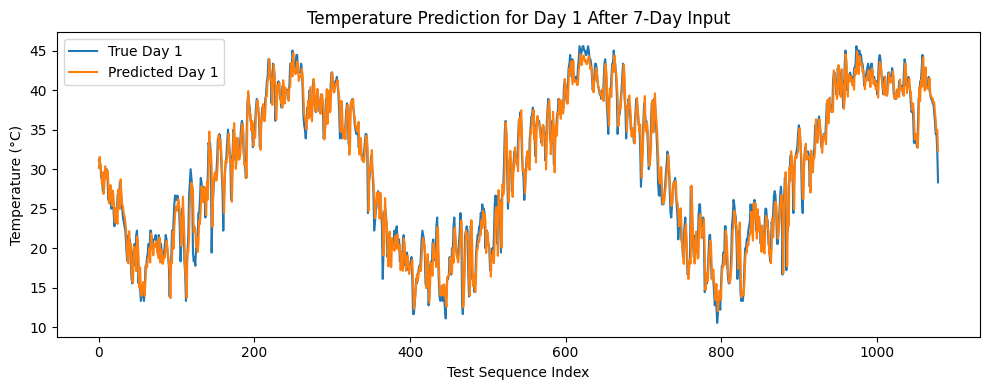

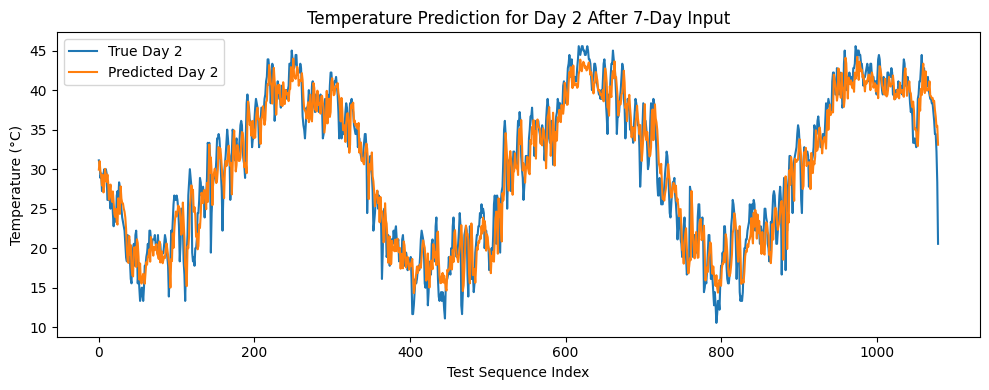

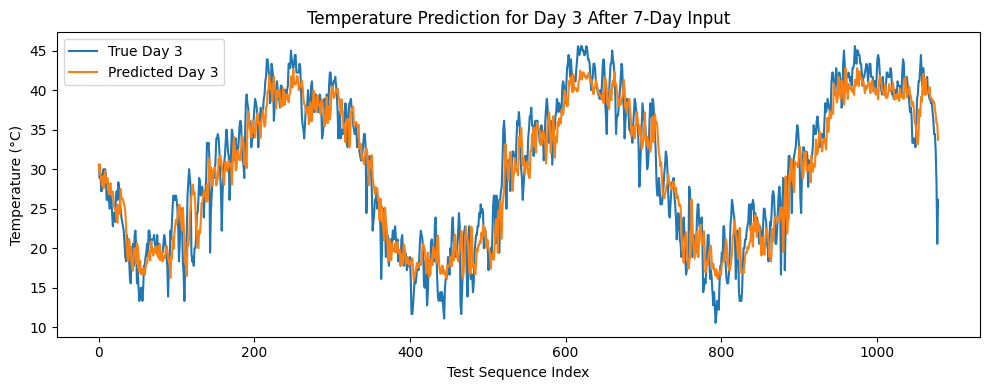

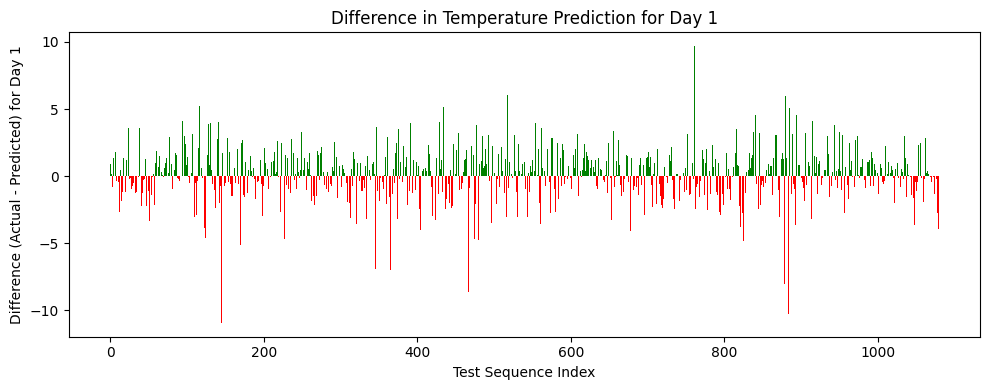

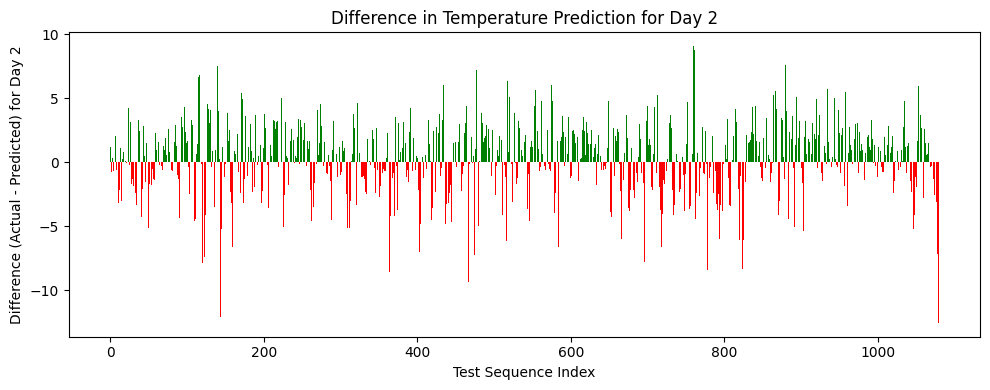

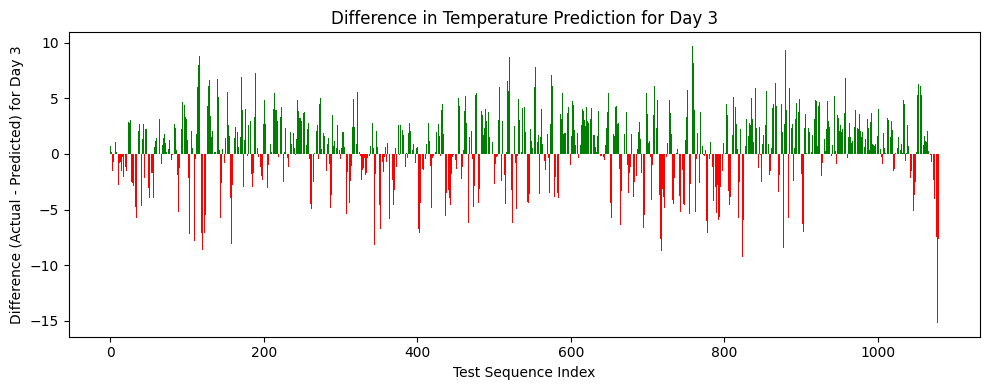


Metrics for Day 1 Prediction:
R² Score: 0.9540
Mean Squared Error (MSE): 3.8492
Mean Absolute Error (MAE): 1.4436
Root Mean Squared Error (RMSE): 1.9619

Metrics for Day 2 Prediction:
R² Score: 0.9006
Mean Squared Error (MSE): 8.3160
Mean Absolute Error (MAE): 2.2199
Root Mean Squared Error (RMSE): 2.8837

Metrics for Day 3 Prediction:
R² Score: 0.8642
Mean Squared Error (MSE): 11.3669
Mean Absolute Error (MAE): 2.6795
Root Mean Squared Error (RMSE): 3.3715


In [28]:
for day in range(prediction_length):
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_inv[:, day], label=f'True Day {day+1}')
    plt.plot(y_pred_inv[:, day], label=f'Predicted Day {day+1}')
    plt.xlabel('Test Sequence Index')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Temperature Prediction for Day {day+1} After {sequence_length}-Day Input')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Step 6: Difference bar chart ---

diff = y_test_inv - y_pred_inv
for day in range(prediction_length):
    plt.figure(figsize=(10, 4))
    colors = np.where(diff[:, day] >= 0, 'green', 'red')
    for i in range(len(diff)):
        plt.bar(i, diff[i, day], color=colors[i])
    plt.xlabel('Test Sequence Index')
    plt.ylabel(f'Difference (Actual - Predicted) for Day {day+1}')
    plt.title(f'Difference in Temperature Prediction for Day {day+1}')
    plt.tight_layout()
    plt.show()

# --- Step 7: Evaluation metrics ---

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for day in range(prediction_length):
    r2 = r2_score(y_test_inv[:, day], y_pred_inv[:, day])
    mse = mean_squared_error(y_test_inv[:, day], y_pred_inv[:, day])
    mae = mean_absolute_error(y_test_inv[:, day], y_pred_inv[:, day])
    rmse = np.sqrt(mse)

    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"\nMetrics for Day {day+1} Prediction:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,611 (14.11 KB)

 Trainable params: 1,203 (4.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,408 (9.41 KB)